In [ ]:
# %%

# Import library
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import tree

In [ ]:
# %%

# Load wine dataset
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target

# Tampilkan deskripsi statistik
print(df_wine.describe().T)

                              count        mean         std     min       25%  \
alcohol                       178.0   13.000618    0.811827   11.03   12.3625   
malic_acid                    178.0    2.336348    1.117146    0.74    1.6025   
ash                           178.0    2.366517    0.274344    1.36    2.2100   
alcalinity_of_ash             178.0   19.494944    3.339564   10.60   17.2000   
magnesium                     178.0   99.741573   14.282484   70.00   88.0000   
total_phenols                 178.0    2.295112    0.625851    0.98    1.7425   
flavanoids                    178.0    2.029270    0.998859    0.34    1.2050   
nonflavanoid_phenols          178.0    0.361854    0.124453    0.13    0.2700   
proanthocyanins               178.0    1.590899    0.572359    0.41    1.2500   
color_intensity               178.0    5.058090    2.318286    1.28    3.2200   
hue                           178.0    0.957449    0.228572    0.48    0.7825   
od280/od315_of_diluted_wines

In [ ]:
# %%

# Tampilkan beberapa data awal
print(df_wine.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

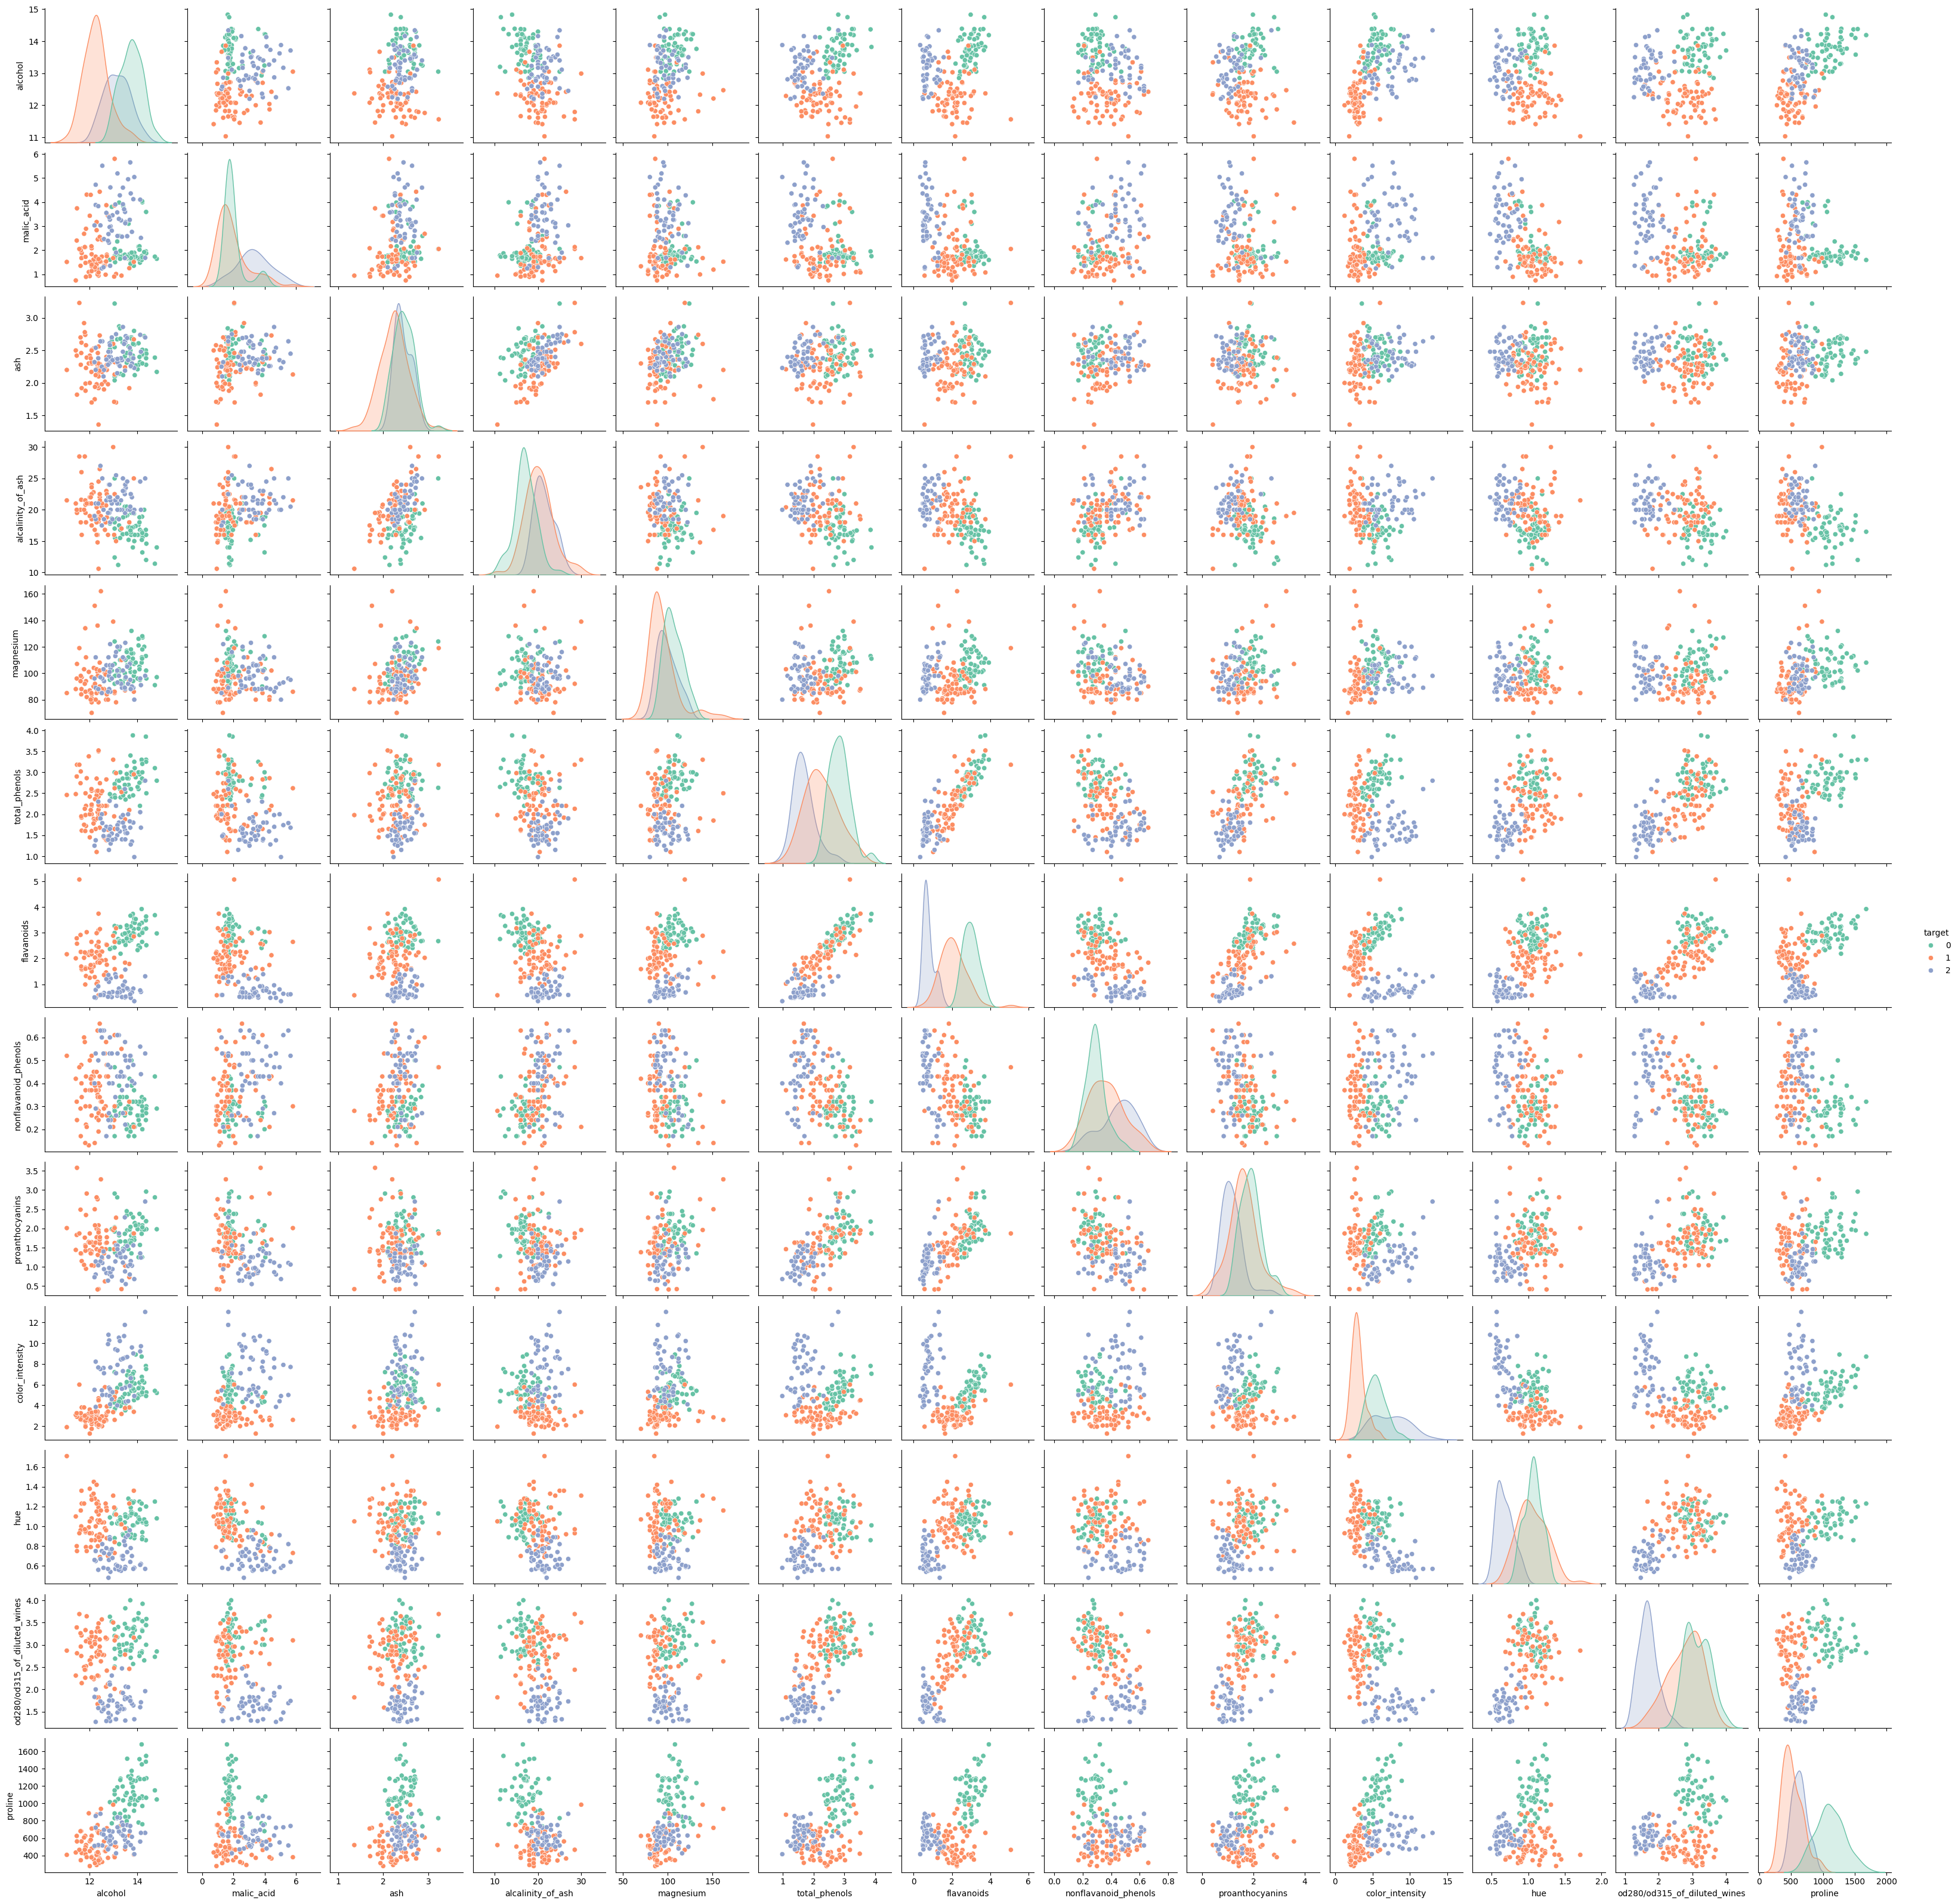

In [ ]:
# %%

# Visualisasi data dengan pairplot
sns.pairplot(df_wine, hue='target', palette='Set2')  # optional
plt.show()

In [ ]:
# %%

# Split data training dan testing
x = df_wine.drop('target', axis=1)
y = df_wine['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
# %%

# Training model
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

# Prediksi
y_pred = model.predict(x_test)

In [ ]:
# %%

# Evaluasi model
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



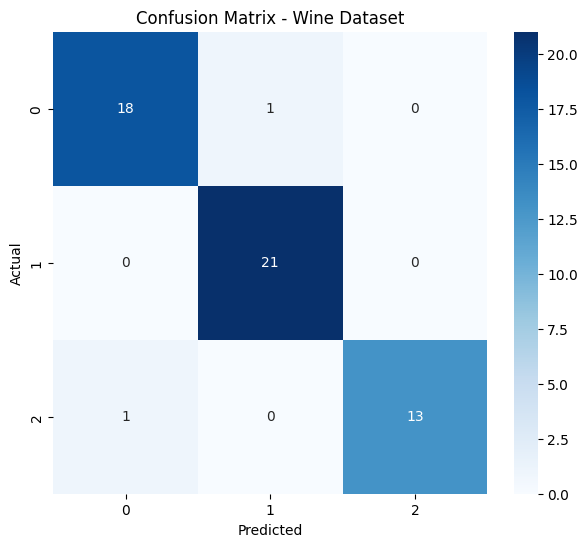

In [ ]:
# %%

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Wine Dataset")
plt.show()

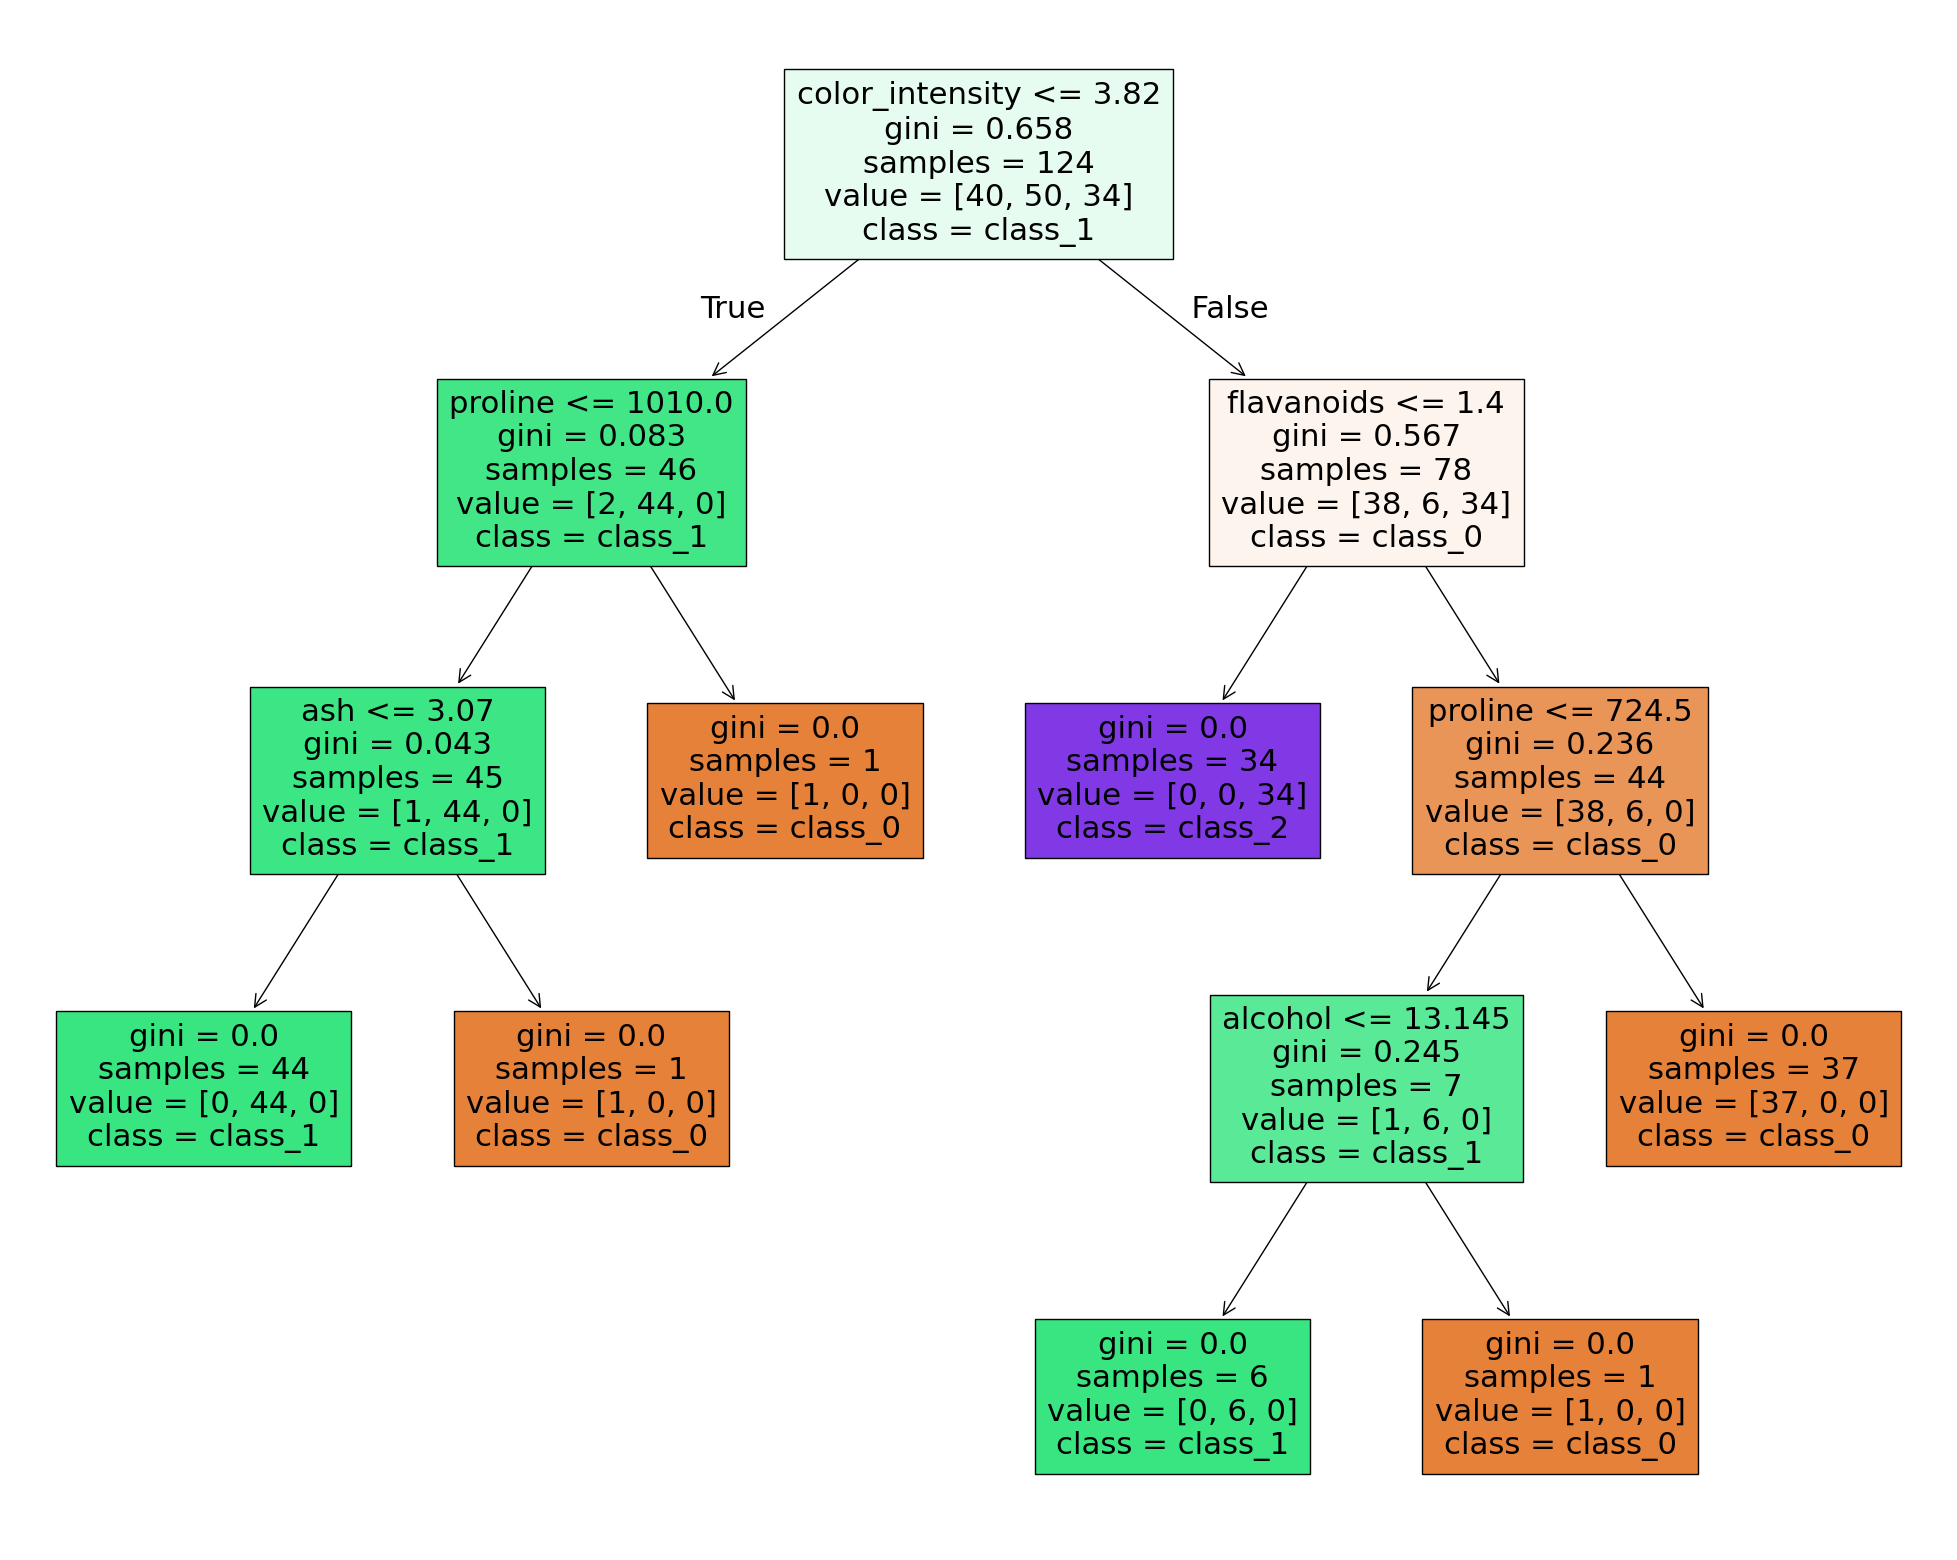

In [ ]:
# %%

# Visualisasi decision tree
fig, ax = plt.subplots(figsize=(25, 20))
tree.plot_tree(model, feature_names=wine.feature_names, class_names=wine.target_names, filled=True)
plt.show()

In [ ]:
# %%

# Uji coba prediksi data baru
wine_test_data = {
    'alcohol': 13.0,
    'malic_acid': 2.0,
    'ash': 2.5,
    'alcalinity_of_ash': 15.0,
    'magnesium': 100.0,
    'total_phenols': 2.0,
    'flavanoids': 2.5,
    'nonflavanoid_phenols': 0.3,
    'proanthocyanins': 1.5,
    'color_intensity': 5.0,
    'hue': 1.0,
    'od280/od315_of_diluted_wines': 3.0,
    'proline': 1000.0
}
input_df = pd.DataFrame([wine_test_data])
prediction = model.predict(input_df[wine.feature_names])
print("Prediksi kelas wine:", prediction)

Prediksi kelas wine: [0]
